In [1]:
import sys, os

# Change working directory to project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# CUDA extension submodules (editable install paths)
sys.path.insert(0, '/home/xiao/0_codes/PIN-WM/diff_rendering/gaussian_splatting_2d/submodules/simple-knn')
sys.path.insert(0, '/home/xiao/0_codes/PIN-WM/diff_rendering/gaussian_splatting_2d/submodules/diff-surfel-rasterization')

# Torch libs for the .so runtime linking
os.environ['LD_LIBRARY_PATH'] = '/home/xiao/miniconda3/envs/pinwm310/lib/python3.10/site-packages/torch/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

print(f"Working directory: {os.getcwd()}")

Working directory: /home/xiao/0_codes/PIN-WM


In [2]:
from diff_rendering.gaussian_splatting_2d.scene.gaussian_model import GaussianModel
from diff_rendering.gaussian_splatting_2d.gaussian_renderer import render
from diff_rendering.gaussian_splatting_2d.utils.camera_utils import cameraList_from_camInfos
from diff_rendering.gaussian_splatting_2d.scene.dataset_readers import sceneLoadTypeCallbacks
from diff_rendering.gaussian_splatting_2d.arguments import PipelineParams
from argparse import ArgumentParser, Namespace
import torch

# 1. Load the trained model
gaussians = GaussianModel(sh_degree=3)
ply_path = "output/tomato_can_static/static/point_cloud/iteration_5000/point_cloud.ply"
gaussians.load_ply(ply_path)

# 2. Load camera(s) — reuse your transforms_test.json
scene_info = sceneLoadTypeCallbacks["Blender"](
    "dataset/tomato_can_static", white_background=True, eval=True
)

args = Namespace(
    data_device="cuda",
    white_background=True,
    resolution=1,
    model_path="",
    source_path="dataset/tomato_can_static",
)

cameras = cameraList_from_camInfos(scene_info.test_cameras, 1.0, args)

# 3. Render
parser = ArgumentParser()
pipe = PipelineParams(parser).extract(parser.parse_args([]))
background = torch.tensor([1, 1, 1], dtype=torch.float32, device="cuda")

render_pkg = render(cameras[0], gaussians, pipe, background)

rendered_image = render_pkg["render"]       # RGB image (3, H, W)
alpha_map = render_pkg["rend_alpha"]        # opacity
depth_map = render_pkg["surf_depth"]        # surface depth
normal_map = render_pkg["surf_normal"]      # surface normals

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Reading Training Transforms
Reading Test Transforms


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031541727..1.0057799].


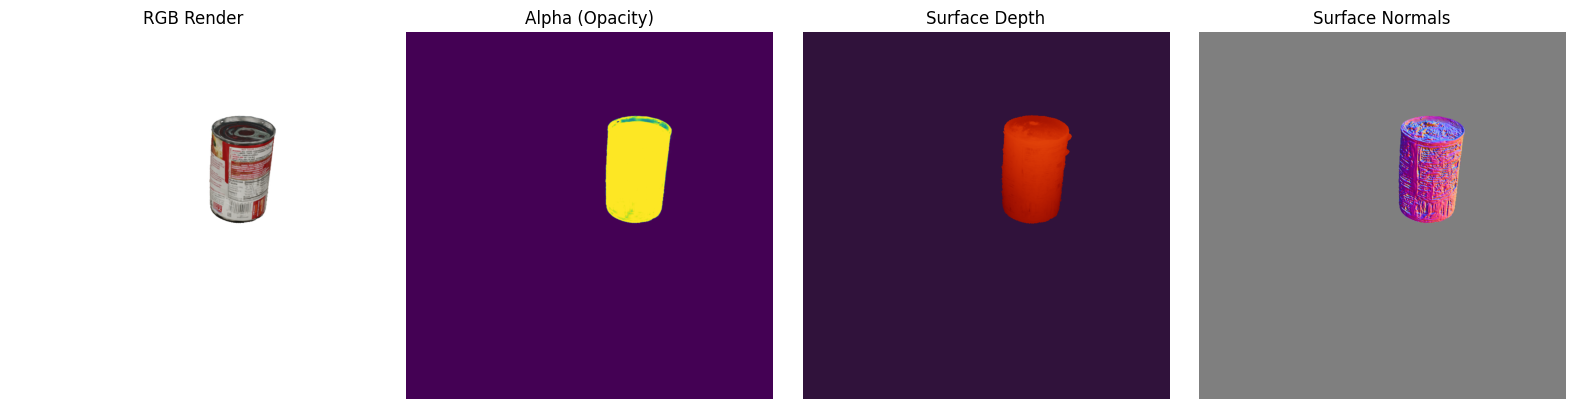

In [3]:
import matplotlib.pyplot as plt
import torch

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# RGB
img = rendered_image.permute(1, 2, 0).cpu().detach()
axes[0].imshow(img)
axes[0].set_title("RGB Render")
axes[0].axis("off")

# Alpha / opacity
alpha = alpha_map.squeeze(0).cpu().detach()
axes[1].imshow(alpha, cmap="viridis")
axes[1].set_title("Alpha (Opacity)")
axes[1].axis("off")

# Surface depth
depth = depth_map.squeeze(0).cpu().detach()
depth = depth / depth.max()  # normalize
axes[2].imshow(depth, cmap="turbo")
axes[2].set_title("Surface Depth")
axes[2].axis("off")

# Surface normals
normal = normal_map.permute(1, 2, 0).cpu().detach()
normal = (normal * 0.5 + 0.5).clamp(0, 1)  # map [-1,1] → [0,1]
axes[3].imshow(normal)
axes[3].set_title("Surface Normals")
axes[3].axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25359988..1.0].


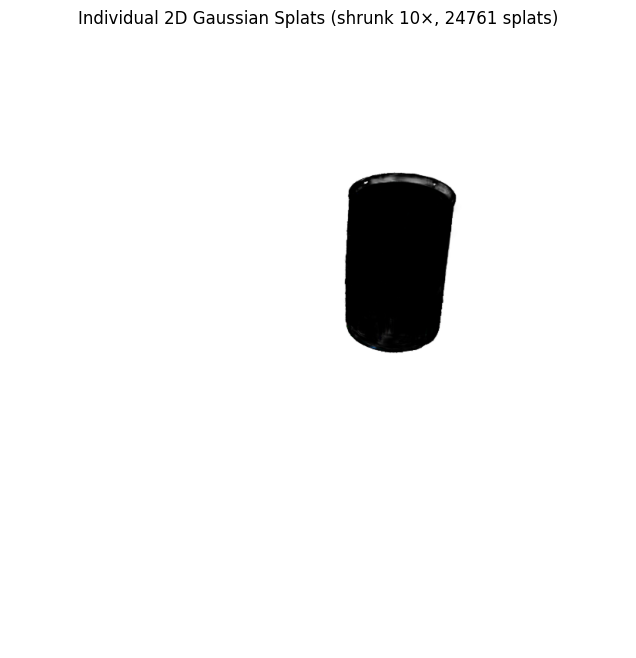

Number of splats: 24761
XYZ range: x=[-0.043, 0.024], y=[0.051, 0.118], z=[-0.023, 0.113]


In [4]:
# --- Visualize individual 2D Gaussian splats ---
import matplotlib.pyplot as plt
import torch

# Render with scaled-down splats to see them as ellipses
render_pkg_tiny = render(
    cameras[0], gaussians, pipe, background,
    scaling_modifier=0.1,          # shrink splats so they don't overlap
    override_color=torch.tensor([0.2, 0.6, 1.0], device="cuda")  # uniform blue color
)

splats_img = render_pkg_tiny["render"].permute(1, 2, 0).cpu().detach()

plt.figure(figsize=(8, 8))
plt.imshow(splats_img)
plt.title(f"Individual 2D Gaussian Splats (shrunk 10×, {gaussians.get_xyz.shape[0]} splats)")
plt.axis("off")
plt.show()

# Also show stats
xyz = gaussians.get_xyz
print(f"Number of splats: {xyz.shape[0]}")
print(f"XYZ range: x=[{xyz[:,0].min():.3f}, {xyz[:,0].max():.3f}], "
      f"y=[{xyz[:,1].min():.3f}, {xyz[:,1].max():.3f}], "
      f"z=[{xyz[:,2].min():.3f}, {xyz[:,2].max():.3f}]")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031541727..1.0057799].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031541727..1.0057799].


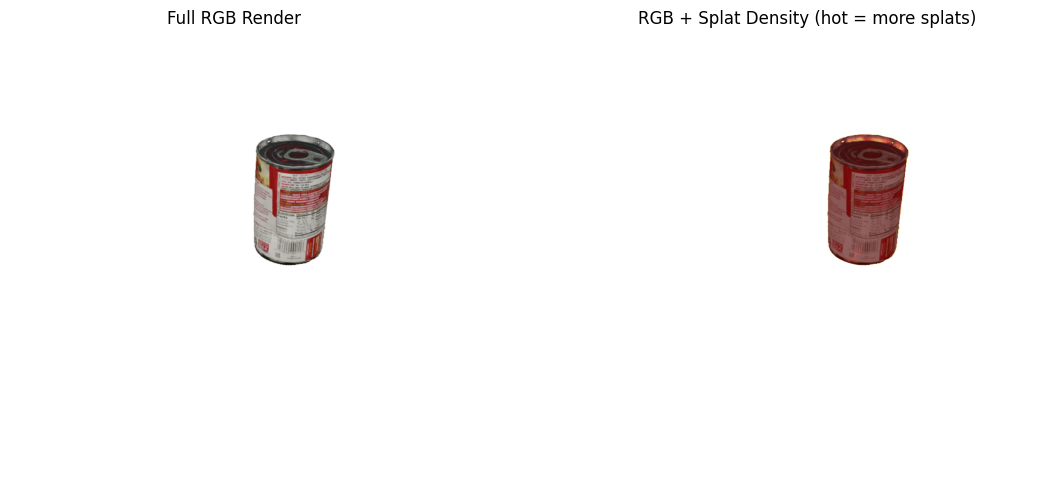

In [5]:
# --- Compare: where splats concentrate vs the actual texture ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: the full RGB render (what the model sees)
rgb = rendered_image.permute(1, 2, 0).cpu().detach()
axes[0].imshow(rgb)
axes[0].set_title("Full RGB Render")
axes[0].axis("off")

# Right: splat distribution overlay - brightness = more splats
splats_img = render_pkg_tiny["render"].permute(1, 2, 0).cpu().detach()
# convert to grayscale for density visualization
density = splats_img.mean(dim=-1)
axes[1].imshow(rgb)
axes[1].imshow(density, alpha=0.5, cmap="hot")
axes[1].set_title("RGB + Splat Density (hot = more splats)")
axes[1].axis("off")

plt.tight_layout()
plt.show()